# Самописный Random Forest



In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('preprocessed_data.csv')
df.shape



(2013, 22)

### Реализация случайного леса

Используем дерево решений из sklearn, реализуем бутстрап, n_estimators, max_depth, max_features. Для анализа полученной модели при обучении рассчитываем feature_importance.


In [232]:
class ManualRandomForest(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=100, max_depth=None, max_features='sqrt',
                 min_samples_leaf=1, min_samples_split=2,
                 bootstrap=True, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.trees = []
        self.feature_indices = []
        self.feature_importances_ = None

    def _get_max_features(self, n_features):
        if self.max_features == 'sqrt':
            return int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            return int(np.log2(n_features))
        elif isinstance(self.max_features, float):
            return int(self.max_features * n_features)
        else:
            return n_features

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.trees = []
        self.feature_indices = []
        self.feature_importances_ = np.zeros(n_features)
        y_values = y.values if hasattr(y, 'values') else y

        max_features = self._get_max_features(n_features)
        for i in range(self.n_estimators):
            if self.bootstrap:
                indices = np.random.choice(n_samples, n_samples, replace=True)
            else:
                indices = np.arange(n_samples)
            feature_idx = np.random.choice(n_features, max_features, replace=False)
            self.feature_indices.append(feature_idx)

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                min_samples_split=self.min_samples_split,
                random_state=self.random_state + i
            )
            tree.fit(X[indices][:, feature_idx], y_values[indices])
            self.trees.append(tree)

            tree_importances = np.zeros(n_features)
            tree_importances[feature_idx] = tree.feature_importances_
            self.feature_importances_ += tree_importances

        self.feature_importances_ /= self.n_estimators
        return self

    def predict(self, X):
        predictions = np.array([
            tree.predict(X[:, feature_idx])
            for tree, feature_idx in zip(self.trees, self.feature_indices)
        ])
        return predictions.mean(axis=0)


### Подготовка данных



In [233]:
numeric_features = [
    'diagonal_inches', 'PPI', 'frequency_hz',
    'contrast_ratio', 'brightness_cd', 'response_time_ms',
    'total_characteristics', 'aspect_ratio', 'is_gaming', 'is_premium'
]

categorical_features = ['matrix_type', 'diagonal_category', 'resolution_category'] # удалены бренды из-за отсутствия импакта

df_encoded = pd.get_dummies(df, columns=categorical_features, dummy_na=False, drop_first=True)

y = df_encoded['log_target']

features_to_use = [col for col in df_encoded.columns
                   if col in numeric_features or
                   col.startswith(tuple(cat + '_' for cat in categorical_features))]

X = df_encoded[features_to_use]

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_imputed, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42 # чтобы тест и валид были одного размера и не пересекались
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (1409, 21), Val: (302, 21), Test: (302, 21)


### Проверка модели



In [234]:
manual_rf_initial = ManualRandomForest(
    n_estimators=100,
    max_depth=20,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

manual_rf_initial.fit(X_train, y_train)

y_val_pred_log = manual_rf_initial.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)
y_val_true = np.expm1(y_val)

mae_initial = mean_absolute_error(y_val_true, y_val_pred)
rmse_initial = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2_initial = r2_score(y_val_true, y_val_pred)

print(f"  MAE: {mae_initial:.2f}")
print(f"  RMSE: {rmse_initial:.2f}")
print(f"  R²: {r2_initial:.4f}")



  MAE: 10459.57
  RMSE: 15136.11
  R²: 0.4188


### Подбираем гиперпараметры

Ищем: n_estimators, max_depth, max_features, min_samples_split, min_samples_list, max_features
Bootstrap True всегда из-за высокой дисперсии данных и ковариации.


In [235]:
param_grid = {
    'n_estimators': [200, 250, 500, 700],
    'max_depth': [5, 10, 14, 16, 18],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [0.5, 0.7, 0.9],
    'bootstrap': [True],
}

def mae_scorer_func(y_true, y_pred):
    return -mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

mae_scorer = make_scorer(mae_scorer_func, greater_is_better=True)

grid_search = GridSearchCV(
    estimator=ManualRandomForest(random_state=42),
    param_grid=param_grid,
    scoring=mae_scorer,
    n_jobs=-1,
)

grid_search.fit(X_val, y_val)

print(f"\nЛучшие параметры: {grid_search.best_params_}")



Лучшие параметры: {'bootstrap': True, 'max_depth': 18, 'max_features': 0.7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 700}


### Проверка лучшей модели



In [236]:
best_manual_rf = grid_search.best_estimator_

y_val_pred_log = best_manual_rf.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)

mae_val = mean_absolute_error(y_val_true, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2_val = r2_score(y_val_true, y_val_pred)

print(f"  Valid:")
print(f"  MAE: {mae_val:.2f}")
print(f"  RMSE: {rmse_val:.2f}")
print(f"  R²: {r2_val:.4f}")

y_test_pred_log = best_manual_rf.predict(X_test)
y_test_pred = np.expm1(y_test_pred_log)
y_test_true = np.expm1(y_test)

mae_test = mean_absolute_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
r2_test = r2_score(y_test_true, y_test_pred)

print(f"  Test:")
print(f"  MAE: {mae_test:.2f}")
print(f"  RMSE: {rmse_test:.2f}")
print(f"  R²: {r2_test:.4f}")

y_test_pred_log = best_manual_rf.predict(X_train)
y_test_pred = np.expm1(y_test_pred_log)
y_test_true = np.expm1(y_train)

mae_test = mean_absolute_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
r2_test = r2_score(y_test_true, y_test_pred)

print(f"\nTrain:")
print(f"  MAE: {mae_test:.2f}")
print(f"  RMSE: {rmse_test:.2f}")
print(f"  R²: {r2_test:.4f}")



  Valid:
  MAE: 5537.21
  RMSE: 8488.59
  R²: 0.8172
  Test:
  MAE: 9558.21
  RMSE: 14346.30
  R²: 0.4742

Train:
  MAE: 10065.94
  RMSE: 14493.48
  R²: 0.5644


Полученные результаты с точностью до погрешности повторяют работу готовой модели случайного леса из sklearn. Можно судить о верной имлементации алгоритмов обучения и применения гиперпараметров.

### Анализ Feature Importance

После анализа было принято решение не использовать признак "бренд".



Топ 20 метрик:
                       Feature  Importance
17  resolution_category_FullHD    0.218334
5                brightness_cd    0.197099
0              diagonal_inches    0.126262
6             response_time_ms    0.090192
3                 frequency_hz    0.084827
2                          PPI    0.084644
4               contrast_ratio    0.065836
9             matrix_type_OLED    0.030498
1                 aspect_ratio    0.015494
19     resolution_category_QHD    0.013891
13              matrix_type_VA    0.013392
15     diagonal_category_Small    0.013151
16    diagonal_category_XLarge    0.011586
7                    is_gaming    0.009977
14    diagonal_category_Medium    0.008208
11              matrix_type_TN    0.006156
8                   is_premium    0.005270
18      resolution_category_HD    0.003157
10           matrix_type_Other    0.001648
12         matrix_type_Unknown    0.000379


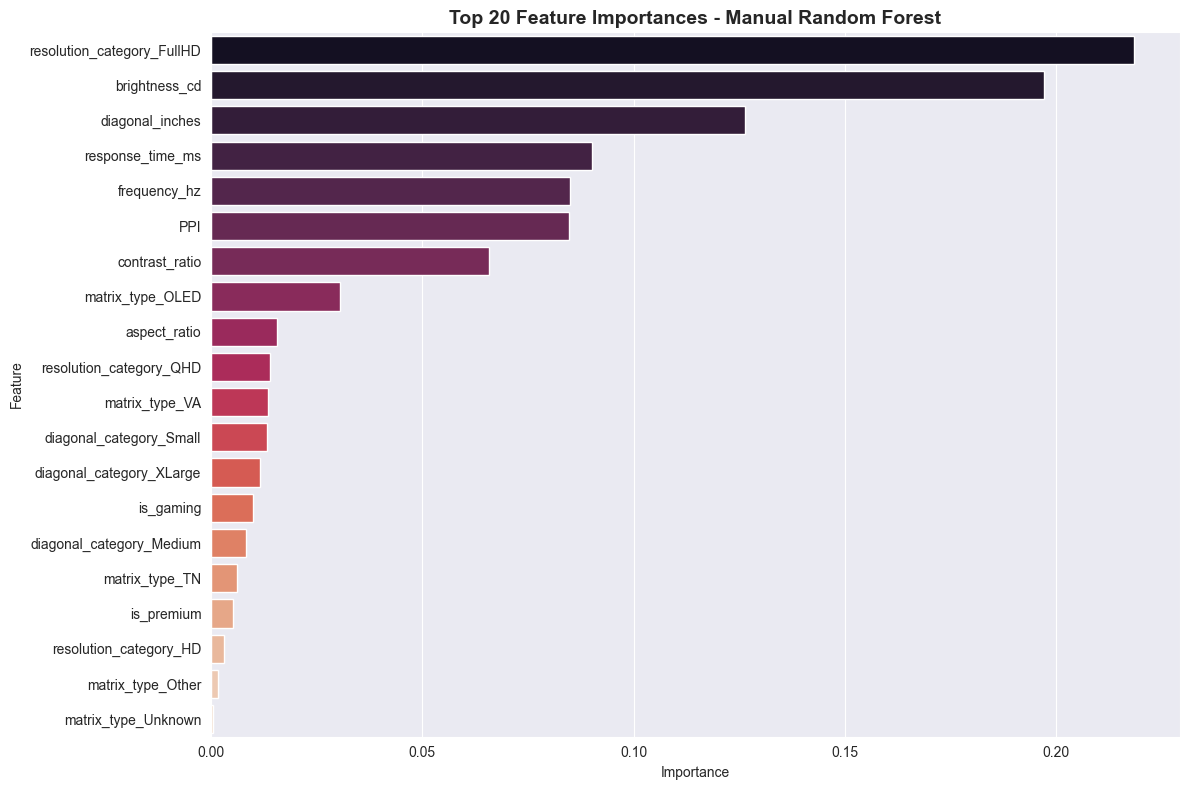

In [237]:
importances = best_manual_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nТоп 20 метрик:")
print(feature_importance_df.head(20))

plt.figure(figsize=(12, 8))
top_n = 20
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(top_n), palette='rocket')
plt.title(f'Top {top_n} Feature Importances - Manual Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



### Визуализация предиктов



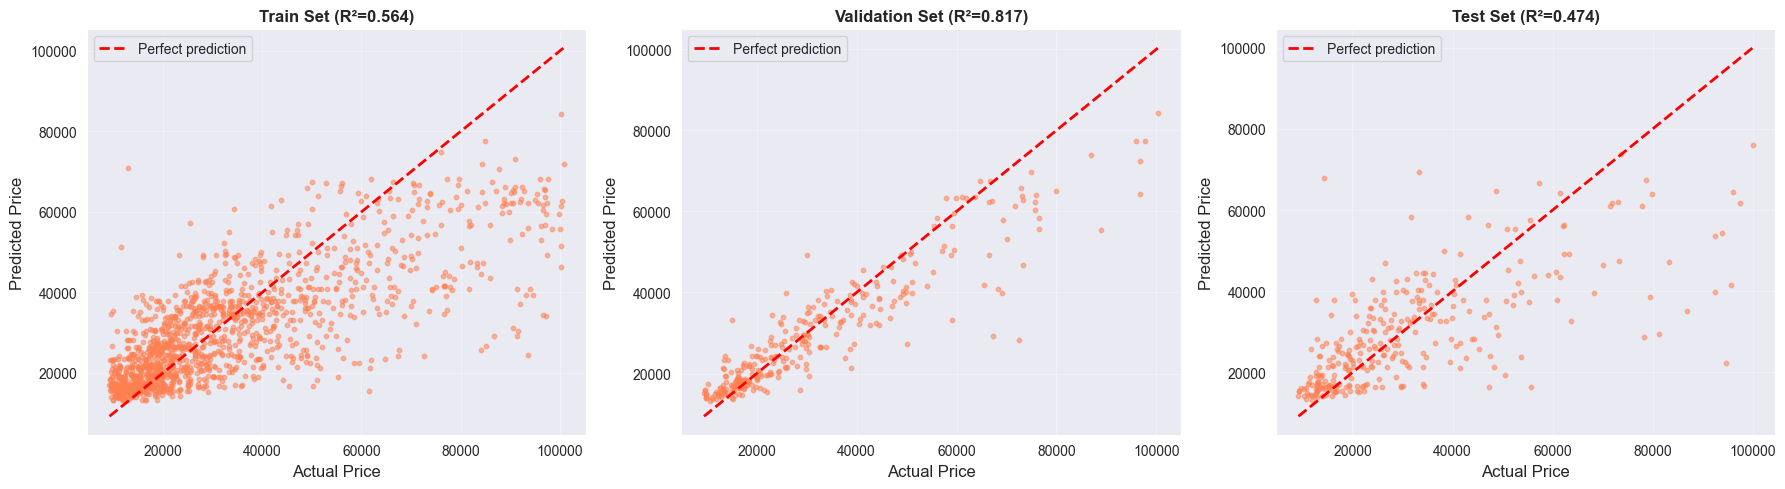

In [238]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (X_train, y_train, 'Train'),
    (X_val, y_val, 'Validation'),
    (X_test, y_test, 'Test')
]

for ax, (X, y, name) in zip(axes, datasets):
    y_pred_log = best_manual_rf.predict(X)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y)

    ax.scatter(y_true, y_pred, alpha=0.5, s=10, color='coral')
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Price', fontsize=12)
    ax.set_ylabel('Predicted Price', fontsize=12)
    ax.set_title(f'{name} Set (R²={r2_score(y_true, y_pred):.3f})', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

